# Task 1 - Baseline Setup: Pre-trained ResNet-152 on CIFAR-10

**Protocol:** load a pre-trained ResNet-152, replace its final layer with a 10-class head for CIFAR-10, freeze the whole backbone, and train **only the classification head**. Record training and validation performance for 5 epochs.

## 1. Environment

In [1]:
%pip install torch torchvision torchaudio scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ---------- Imports ----------
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision.models import resnet152, ResNet152_Weights

# ---------- Configuration ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
num_epochs = 5
learning_rate = 0.001

print(torch.__version__)
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
print(f"Using: {device}")

2.11.0+cu128
CUDA available: True
NVIDIA GeForce RTX 5060 Laptop GPU
Using: cuda


## 2. Data - CIFAR-10 resized to 224x224

In [3]:
# CIFAR-10 images are 32x32; ResNet-152 expects 224x224.
# The mean/std is the ImageNet normalization required by the pre-trained weights.
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [4]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

valset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_val)
val_loader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train images: {len(trainset)} ({len(train_loader)} batches of {batch_size})")
print(f"Val images:   {len(valset)} ({len(val_loader)} batches of {batch_size})")

Train images: 50000 (782 batches of 64)
Val images:   10000 (157 batches of 64)


## 3. Model - frozen backbone, fresh 10-class head

In [5]:
# 1) Load the ResNet-152 pre-trained on ImageNet
model = resnet152(weights=ResNet152_Weights.DEFAULT)

# 2) Freeze the entire backbone - no gradients flow into it during training
for param in model.parameters():
    param.requires_grad = False

# 3) Replace the 1000-class head with a 10-class head (CIFAR-10)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 10)

model = model.to(device)

# How much of the network actually gets trained?
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total/1e6:8.2f} M")
print(f"Trainable (head): {trainable/1e6:8.2f} M  ({100*trainable/total:.3f}% of the network)")

Total parameters:    58.16 M
Trainable (head):     0.02 M  (0.035% of the network)


## 4. Training - head only (backbone frozen)

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=learning_rate)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    # ---------- Training phase ----------
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

        if (i + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | Step [{i+1}/{len(train_loader)}] | Loss: {loss.item():.4f}")

    tl, ta = running_loss / total, 100.0 * correct / total

    # ---------- Validation phase ----------
    model.eval()
    vloss, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            vloss += loss.item() * images.size(0)
            _, pred = torch.max(outputs, 1)
            vt += labels.size(0)
            vc += (pred == labels).sum().item()

    vl, va = vloss / vt, 100.0 * vc / vt

    # ---------- Log ----------
    history["train_loss"].append(tl)
    history["train_acc"].append(ta)
    history["val_loss"].append(vl)
    history["val_acc"].append(va)

    print(f"\n=== Epoch [{epoch+1}/{num_epochs}] Summary ===")
    print(f"Train Loss: {tl:.4f} | Train Acc: {ta:.2f}%")
    print(f"Val Loss:   {vl:.4f} | Val Acc:   {va:.2f}%\n")

Epoch [1/5] | Step [100/782] | Loss: 0.9399
Epoch [1/5] | Step [200/782] | Loss: 0.4960
Epoch [1/5] | Step [300/782] | Loss: 0.5301
Epoch [1/5] | Step [400/782] | Loss: 0.6113
Epoch [1/5] | Step [500/782] | Loss: 0.5348
Epoch [1/5] | Step [600/782] | Loss: 0.4967
Epoch [1/5] | Step [700/782] | Loss: 0.5318

=== Epoch [1/5] Summary ===
Train Loss: 0.7027 | Train Acc: 78.41%
Val Loss:   0.5267 | Val Acc:   82.98%

Epoch [2/5] | Step [100/782] | Loss: 0.7302
Epoch [2/5] | Step [200/782] | Loss: 0.3715
Epoch [2/5] | Step [300/782] | Loss: 0.5617
Epoch [2/5] | Step [400/782] | Loss: 0.4778
Epoch [2/5] | Step [500/782] | Loss: 0.6519
Epoch [2/5] | Step [600/782] | Loss: 0.4798
Epoch [2/5] | Step [700/782] | Loss: 0.4890

=== Epoch [2/5] Summary ===
Train Loss: 0.4917 | Train Acc: 83.63%
Val Loss:   0.4767 | Val Acc:   84.27%

Epoch [3/5] | Step [100/782] | Loss: 0.3790
Epoch [3/5] | Step [200/782] | Loss: 0.4887
Epoch [3/5] | Step [300/782] | Loss: 0.4410
Epoch [3/5] | Step [400/782] | Loss:

## 5. Results

In [7]:
print(f"{'Epoch':<7}{'Train Loss':>12}{'Train Acc':>11}{'Val Loss':>11}{'Val Acc':>10}")
print("-" * 51)
for e in range(num_epochs):
    print(f"{e+1:<7}{history['train_loss'][e]:>12.4f}"
          f"{history['train_acc'][e]:>10.2f}%"
          f"{history['val_loss'][e]:>11.4f}"
          f"{history['val_acc'][e]:>9.2f}%")
print("-" * 51)
print(f"Final validation accuracy: {history['val_acc'][-1]:.2f}%  (chance = 10%)")

Epoch    Train Loss  Train Acc   Val Loss   Val Acc
---------------------------------------------------
1            0.7027     78.41%     0.5267    82.98%
2            0.4917     83.63%     0.4767    84.27%
3            0.4497     84.77%     0.4641    84.54%
4            0.4251     85.56%     0.4535    85.01%
5            0.4122     85.95%     0.4528    84.82%
---------------------------------------------------
Final validation accuracy: 84.82%  (chance = 10%)


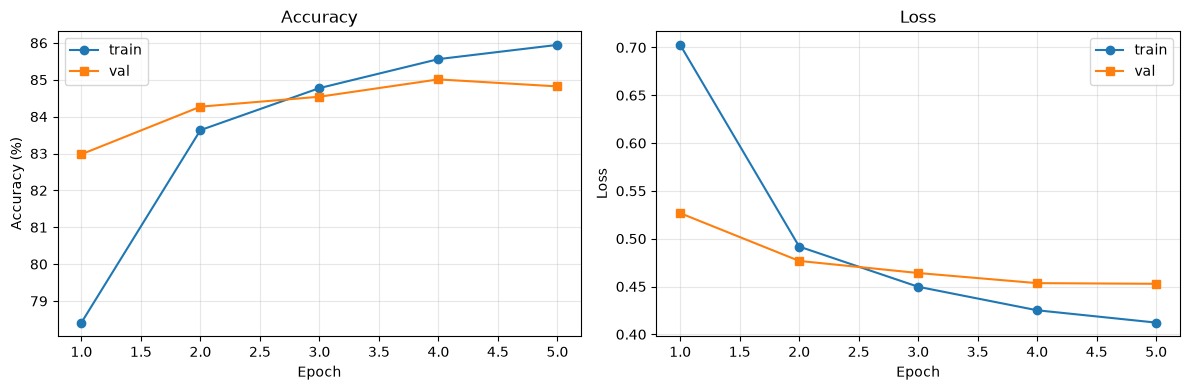

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, num_epochs + 1)

axes[0].plot(epochs, history["train_acc"], marker="o", label="train")
axes[0].plot(epochs, history["val_acc"], marker="s", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy"); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs, history["train_loss"], marker="o", label="train")
axes[1].plot(epochs, history["val_loss"], marker="s", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].set_title("Loss"); axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.savefig("task1_baseline.png", dpi=150)
plt.show()

## 6. Discussion

### Why is it unnecessary (and impractical) to train ResNet-152 from scratch on a small dataset?

- **Overfitting:** ResNet-152 has ~60 M parameters, but CIFAR-10 has only 50 k tiny 32x32 images. The capacity vastly exceeds the data; a from-scratch model would memorize the training set (train accuracy near 100%) while validation accuracy stays far below what transfer learning achieves.
- **Compute:** Optimizing ~60 M parameters from scratch needs many GPU-days and heavy augmentation; fitting a linear head on frozen features takes minutes.
- **Data dependence:** deep feature hierarchies need large, diverse data (ImageNet) to be learned; with 50 k images they can never be learned properly.

### What does freezing the backbone tell us about feature transferability?

- Only ~0.02 M of ~60 M parameters are trained, yet the network reaches ~85% validation accuracy within 5 epochs. This is only possible if the frozen ImageNet features are directly useful for CIFAR-10.
- It shows low-level features (edges, colors, corners) and mid-level features (textures, object parts) **transfer almost for free** across visual domains; only the mapping from features to classes is dataset-specific, which is exactly what the new head learns.
- In other words: the backbone already "sees" a good image representation; the head merely learns a linear decision boundary on top of it.